# 01 – Data Audit

**Purpose:** understand what is actually in the two datasets before deciding on a project question.
For each dataset we look at: what one row means, the time range covered, how many sensors/spaces there are,
what is measured (and in what units), and how much is missing, duplicated or flagged as an error.

**How to use this notebook**
- Run cells in order with **Shift + Enter**. The kernel (top right) should be the `.venv` Python.
- All loading is done by the tested functions in `src/mma3001/io.py` – this notebook only explores.
- Cells marked ✍️ are observations. These feed directly into the *Inputs and outputs*
  section of the report, so write down anything surprising.
- Loading the full occupancy file takes about a minute and needs ~2 GB of free RAM.

In [1]:
# Standard imports. pandas = tables, matplotlib = plots.
import time
import pandas as pd
import matplotlib.pyplot as plt

# Own tested loading functions (from src/mma3001/io.py).
from mma3001.io import load_occupancy, load_env, load_sensor_locations
from mma3001.io import OCCUPANCY_FILE, ENV_FILE

pd.set_option("display.max_columns", 20)   # show all columns when printing tables

---
## Part A – Occupancy data

### A1. What does one row look like?
Load just the first 5 rows to see the structure before loading all ~9 million.

In [2]:
load_occupancy(nrows=5)

,id,deviceid,floorspaceid,occupancystatus,headcount,collecteddate,occupancystatuschangedate,previousoccupancystatus
0,136043,56923747-b390-4f2a-8930-808429132266,941f0352-bb69-47d0-a9c5-ac29eb4f7319,CurrentlyOccupied,1,2023-11-24 00:36:52+11:00,2023-11-24 00:36:52+11:00,NotOccupied
1,136048,56923747-b390-4f2a-8930-808429132266,941f0352-bb69-47d0-a9c5-ac29eb4f7319,RecentlyOccupied,0,2023-11-24 00:37:32+11:00,2023-11-24 00:37:32+11:00,CurrentlyOccupied
2,136050,56923747-b390-4f2a-8930-808429132266,0f3f37f8-0335-41e0-ae87-a1d677dfc7d7,CurrentlyOccupied,1,2023-11-24 00:37:32+11:00,2023-11-24 00:37:32+11:00,NotOccupied
3,136052,56923747-b390-4f2a-8930-808429132266,941f0352-bb69-47d0-a9c5-ac29eb4f7319,NotOccupied,0,2023-11-24 00:37:52+11:00,2023-11-24 00:37:52+11:00,RecentlyOccupied
4,136053,56923747-b390-4f2a-8930-808429132266,0f3f37f8-0335-41e0-ae87-a1d677dfc7d7,RecentlyOccupied,0,2023-11-24 00:37:52+11:00,2023-11-24 00:37:52+11:00,CurrentlyOccupied


### A2. Load the full file
`time.perf_counter()` measures how long the load takes – useful later for the performance section of the report.

In [3]:
t0 = time.perf_counter()
occ = load_occupancy()
print(f"Loaded {len(occ):,} rows in {time.perf_counter() - t0:.1f} s")

occ.info(memory_usage="deep")   # column types and memory used

Loaded 9,091,732 rows in 39.2 s
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9091732 entries, 0 to 9091731
Data columns (total 8 columns):
 #   Column                     Dtype                              
---  ------                     -----                              
 0   id                         int64                              
 1   deviceid                   category                           
 2   floorspaceid               category                           
 3   occupancystatus            category                           
 4   headcount                  int64                              
 5   collecteddate              datetime64[ns, Australia/Melbourne]
 6   occupancystatuschangedate  datetime64[ns, Australia/Melbourne]
 7   previousoccupancystatus    category                           
dtypes: category(4), datetime64[ns, Australia/Melbourne](2), int64(2)
memory usage: 312.1 MB


### A3. What time period does it cover?
The file name says *May to Dec 2024*. Does the data agree?

First record: 2023-11-24 00:36:52+11:00
Last record:  2026-04-22 23:02:38+10:00


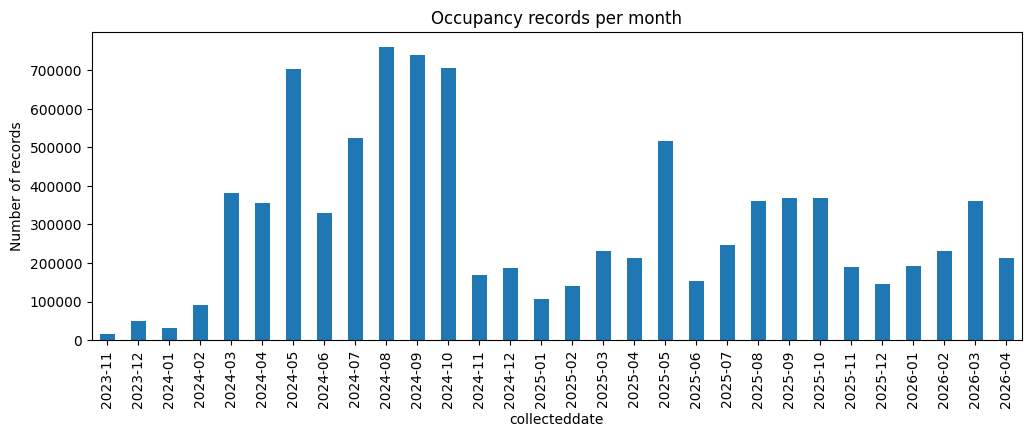

In [4]:
print("First record:", occ["collecteddate"].min())
print("Last record: ", occ["collecteddate"].max())

# Number of records per calendar month.
# (tz_localize(None) keeps the Melbourne clock time but drops the time-zone label,
# which monthly "periods" cannot store.)
per_month = occ["collecteddate"].dt.tz_localize(None).dt.to_period("M").value_counts().sort_index()
ax = per_month.plot(kind="bar", figsize=(12, 4), title="Occupancy records per month")
ax.set_ylabel("Number of records");


 Stated date range is May 2024 - Dec 2024, Actual occupancy range covers from Nov 2023 - Apr 2026.
 Shows general spike in total occupancy across all locations and buildings in mid-late 2024. 
 appears to be dip in occupancy from Nov - Feb each year, makes logical sense given semester dates.
 Depending on date ranges for env sensors, consider Jan2024 - Jan 2026 as range for analysis, shows two full years including seasonality 

### A4. How many sensors and spaces?

In [5]:
print("Distinct devices:      ", occ["deviceid"].nunique())
print("Distinct floor spaces: ", occ["floorspaceid"].nunique())

# How many floor spaces does each device report on?
spaces_per_device = occ.groupby("deviceid", observed=True)["floorspaceid"].nunique()
spaces_per_device.describe()

Distinct devices:       1
Distinct floor spaces:  5


count    1.0
mean     5.0
std      NaN
min      5.0
25%      5.0
50%      5.0
75%      5.0
max      5.0
Name: floorspaceid, dtype: float64

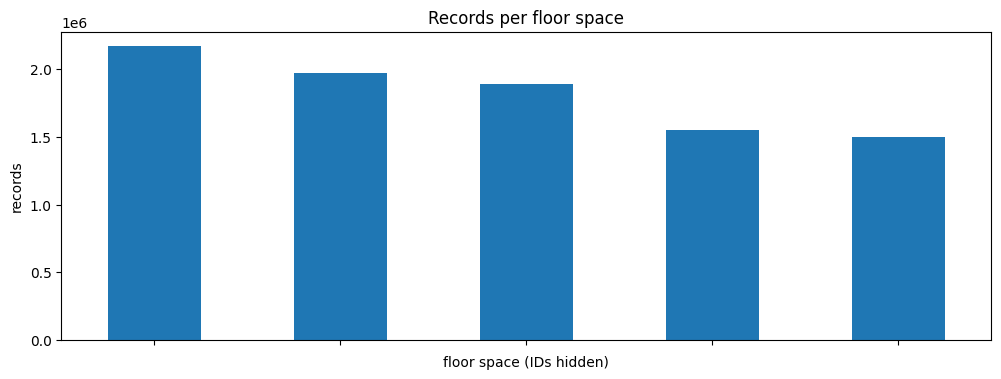

In [6]:
# Records per floor space - are some spaces reported far more than others?
per_space = occ["floorspaceid"].value_counts()
ax = per_space.plot(kind="bar", figsize=(12, 4), title="Records per floor space")
ax.set_xticklabels([]); ax.set_xlabel("floor space (IDs hidden)"); ax.set_ylabel("records");

> ✍️ 
1 device covers 5 distinct floor spaces.
Not every floor space has the same amount of readings, consider range of data for analysis. Likeely would make sense to restrict analysis to a single day/ week/ month etc within which every floor space has the same amount of records. 

### A4b. When does each floor space record, and is it continuous?
The table gives each space's first and last record. The plot shows the number of records per day for each space: a flat line at **0** means that space recorded nothing that day (a gap).

In [7]:
# First record, last record and number of records for each floor space,
# sorted by the date each space starts recording.
span = (occ.groupby("floorspaceid", observed=True)
           .agg(first=("collecteddate", "min"),
                last=("collecteddate", "max"),
                records=("id", "size"))
           .sort_values("first"))
span

,first,last,records
floorspaceid,,,
941f0352-bb69-47d0-a9c5-ac29eb4f7319,2023-11-24 00:36:52+11:00,2026-04-22 23:02:38+10:00,1975423
0f3f37f8-0335-41e0-ae87-a1d677dfc7d7,2023-11-24 00:37:32+11:00,2026-04-22 23:02:18+10:00,2169461
227f1068-9e41-469f-bef0-275f27a0bdba,2024-03-03 15:06:30+11:00,2026-04-22 22:09:42+10:00,1500394
cca1ac3e-f81f-4ebb-aa2b-8b0bf3e9e53b,2024-03-03 15:06:30+11:00,2026-04-22 22:54:50+10:00,1894871
3e5a14df-4b14-4ea5-bb9d-46577c6dc9c8,2024-05-01 00:00:16+10:00,2024-12-30 23:01:56+11:00,1551583


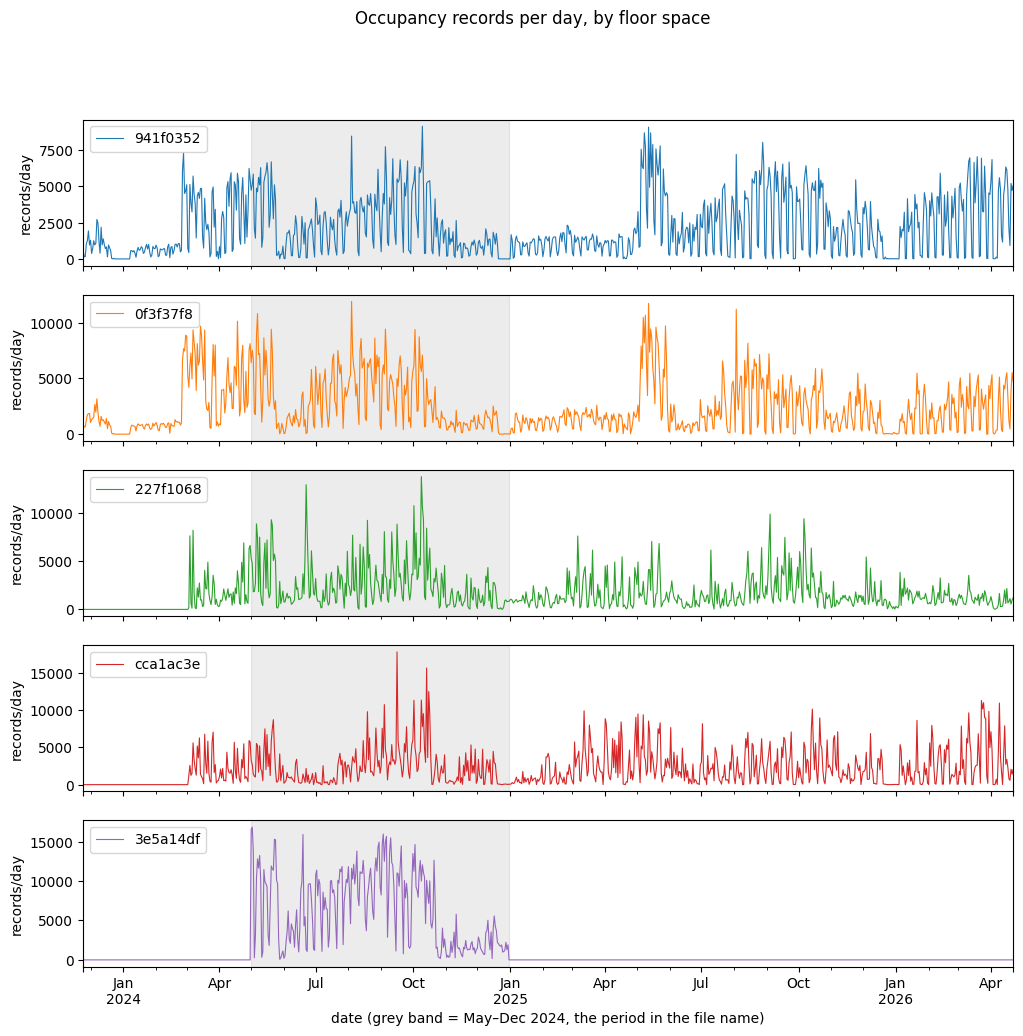

In [8]:
# Count the records per floor space per day.
# pd.Grouper(..., freq="D") groups the timestamps into calendar days (Melbourne time).
daily = (occ.groupby(["floorspaceid", pd.Grouper(key="collecteddate", freq="D")], observed=True)
            .size()                 # number of records in each (space, day) group
            .unstack(level=0)       # one column per floor space, one row per day
            .fillna(0))             # a space with no records on a day -> 0

# Make sure EVERY day in the whole period has a row, so gaps show up as 0
# instead of the plot drawing a straight line across them.
all_days = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
daily = daily.reindex(all_days, fill_value=0)

# Order the columns by start date (as in the table above) and shorten the
# long IDs to their first 8 characters for readable labels.
daily = daily[span.index]
daily.columns = [str(c)[:8] for c in daily.columns]

axes = daily.plot(subplots=True, sharex=True, figsize=(12, 11), linewidth=0.8,
                  title="Occupancy records per day, by floor space")
for ax in axes:
    ax.set_ylabel("records/day")
    # Shade the period the file name claims to cover (May-Dec 2024) for comparison.
    ax.axvspan(pd.Timestamp("2024-05-01", tz="Australia/Melbourne"),
               pd.Timestamp("2024-12-31", tz="Australia/Melbourne"), color="grey", alpha=0.15)
    ax.legend(loc="upper left")
axes[-1].set_xlabel("date (grey band = May–Dec 2024, the period in the file name)");

> ✍️ 
As observed, in cell A3, the actual date range for the dataset exceeds what was listed in the title (May 2024 - Dec 2024)
However, this title makes more physical sense after analysing when the floorIDs are actually recording, as one of them only records for May 2024 - Dec 2024


### A5. What values do the status and head-count columns take?

In [9]:
print(occ["occupancystatus"].value_counts(), "\n")
print(occ["previousoccupancystatus"].value_counts(), "\n")
occ["headcount"].describe()

occupancystatus
CurrentlyOccupied    8405894
RecentlyOccupied      420133
NotOccupied           265705
Name: count, dtype: int64 

previousoccupancystatus
RecentlyOccupied     4775102
NotOccupied          3703402
CurrentlyOccupied     420170
Unknown               193058
Name: count, dtype: int64 



count    9.091732e+06
mean     3.174405e+00
std      3.395244e+00
min      0.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      4.000000e+00
max      7.200000e+01
Name: headcount, dtype: float64

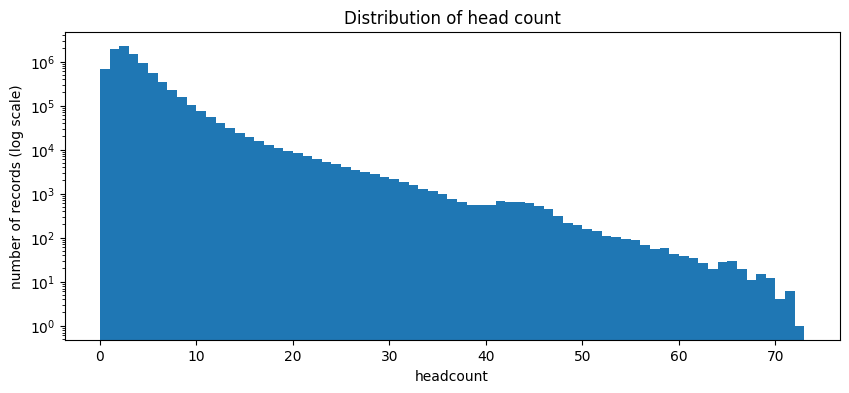

In [10]:
ax = occ["headcount"].plot(kind="hist", bins=range(0, occ["headcount"].max() + 2), figsize=(10, 4),
                           title="Distribution of head count", log=True)
ax.set_xlabel("headcount"); ax.set_ylabel("number of records (log scale)");

In [11]:
# Does headcount agree with the status? e.g. can a space be 'NotOccupied' with people in it?
pd.crosstab(occ["occupancystatus"], occ["headcount"].clip(upper=5), margins=True)

headcount,0,1,2,3,4,5,All
occupancystatus,,,,,,,
CurrentlyOccupied,0,1941153,2294239,1489709,919319,1761474,8405894
NotOccupied,265705,0,0,0,0,0,265705
RecentlyOccupied,420133,0,0,0,0,0,420133
All,685838,1941153,2294239,1489709,919319,1761474,9091732


> ✍️ 
Both the recently occupied and not occupied status line up with the headcounts being 0 for all records, makes sense as the staus is likely just a calculated status based off a conditional heacount rather than a seperate reading or measurement itself. 

### A6. Missing values and duplicates

In [12]:
print("Missing values per column:")
print(occ.isna().sum(), "\n")
print("Duplicate record IDs:  ", occ["id"].duplicated().sum())
print("Fully duplicated rows (ignoring id):", occ.drop(columns="id").duplicated().sum())

Missing values per column:
id                           0
deviceid                     0
floorspaceid                 0
occupancystatus              0
headcount                    0
collecteddate                0
occupancystatuschangedate    0
previousoccupancystatus      0
dtype: int64 

Duplicate record IDs:   0
Fully duplicated rows (ignoring id): 4


> ✍️  No missinng values, beneficial for analysis. 4 duplicated rows, consider removing them before analysis to ensure results aren't affected.

### A7. What does a single space look like over one day?
Pick the busiest space and plot its head count across one weekday. A *step* plot is used because
the count stays the same until the next event arrives.

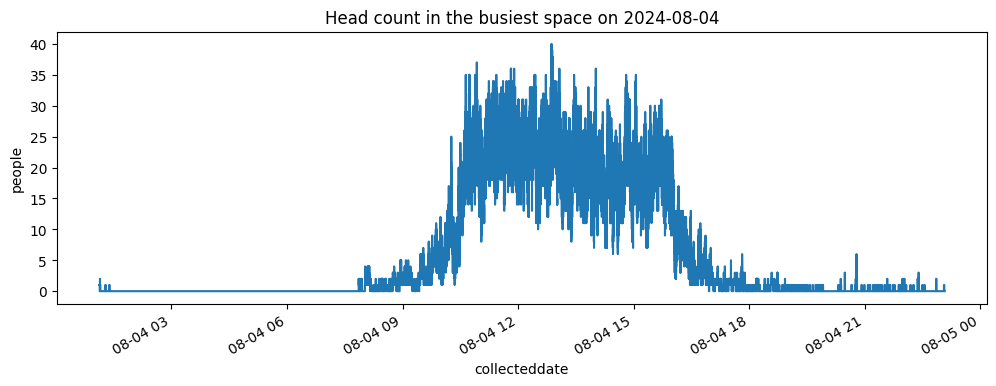

In [13]:
busiest_space = per_space.index[0]
one_space = occ[occ["floorspaceid"] == busiest_space].sort_values("collecteddate")

day = one_space["collecteddate"].dt.date.value_counts().index[0]   # the day with the most records
one_day = one_space[one_space["collecteddate"].dt.date == day]

ax = one_day.plot(x="collecteddate", y="headcount", drawstyle="steps-post", figsize=(12, 4),
                  title=f"Head count in the busiest space on {day}", legend=False)
ax.set_ylabel("people");

> ✍️ 
Headcount could almost be said to follow a normal distribution, centred around roughly 13:30
Makes physical sense when thinking about when a university room would be occupied. 
Very few readings outside of 7:30 - 18:00


---
## Part B – Environmental data

### B1. What does the raw file look like?
Each CSV row holds an **upload** from one sensor, with the readings packed as JSON text in `jsondata`.

In [14]:
raw_env = pd.read_csv(ENV_FILE, nrows=2)
print(raw_env.columns.tolist(), "\n")
print("jsondata of the first row (first 600 characters):\n")
print(raw_env["jsondata"].iloc[0][:600])

['id', 'sensorid', 'devicetype', 'jsondata', 'status', 'processing_errors', 'createdate', 'processdate'] 

jsondata of the first row (first 600 characters):

[{"values": [{"time": 1702273965, "value": 4.1875}], "variable": {"id": 66, "name": "Battery", "unit": "V", "source": 0, "structure": 32834}}, {"values": [{"time": 1702273965, "value": 603}], "variable": {"id": 67, "name": "Carbon dioxide", "unit": "ppm", "source": 0, "structure": 32835}}, {"values": [{"time": 1702273965, "value": 66}], "variable": {"id": 72, "name": "Humidity", "unit": "HR%", "source": 0, "structure": 32840}}, {"values": [{"time": 1702273965, "value": 6}], "variable": {"id": 70, "name": "Formaldehyde", "unit": "µg/m3", "source": 0, "structure": 32847}}, {"values": [{"time": 1


`load_env()` unpacks this into one row per individual reading
(see the docstring in `src/mma3001/io.py` for exactly how).

In [15]:
t0 = time.perf_counter()
env = load_env()
print(f"Unpacked {len(env):,} readings in {time.perf_counter() - t0:.1f} s")
env.head(12)

Unpacked 1,939,224 readings in 8.0 s


,record_id,sensorid,time,variable,unit,value,error_code,createdate
0,2,6012002000241,2023-12-11 16:52:45+11:00,Battery,V,4.1875,NaN,2024-02-29 03:11:58.210358+11:00
1,2,6012002000241,2023-12-11 16:52:45+11:00,Carbon dioxide,ppm,603.0000,NaN,2024-02-29 03:11:58.210358+11:00
2,2,6012002000241,2023-12-11 16:52:45+11:00,Humidity,HR%,66.0000,NaN,2024-02-29 03:11:58.210358+11:00
3,2,6012002000241,2023-12-11 16:52:45+11:00,Formaldehyde,µg/m3,6.0000,NaN,2024-02-29 03:11:58.210358+11:00
4,2,6012002000241,2023-12-11 16:52:45+11:00,Pressure,mb,1011.0000,NaN,2024-02-29 03:11:58.210358+11:00
5,2,6012002000241,2023-12-11 16:52:45+11:00,Temperature,°C,23.8000,NaN,2024-02-29 03:11:58.210358+11:00
6,2,6012002000241,2023-12-11 16:52:45+11:00,Light Volatile Organic Compounds,ppb,14.0000,NaN,2024-02-29 03:11:58.210358+11:00
7,2,6012002000241,2023-12-11 16:52:45+11:00,Particulate matter 1,µg/m3,8.0000,NaN,2024-02-29 03:11:58.210358+11:00
8,2,6012002000241,2023-12-11 16:52:45+11:00,Particulate matter 4,µg/m3,9.0000,NaN,2024-02-29 03:11:58.210358+11:00
9,2,6012002000241,2023-12-11 16:52:45+11:00,Particulate matter 2.5,µg/m3,9.0000,NaN,2024-02-29 03:11:58.210358+11:00


### B2. What is measured, and in what units?

In [16]:
summary = env.groupby(["variable", "unit"], observed=True)["value"].agg(
    readings="size", missing=lambda v: v.isna().sum(), min="min", median="median", max="max")
summary

,,readings,missing,min,median,max
variable,unit,,,,,
Battery,V,179447,0,3.9688,4.1875,4.25
Carbon dioxide,ppm,179447,0,400.0000,520.0000,1387.00
Formaldehyde,µg/m3,179447,113380,1.0000,5.0000,55.00
Humidity,HR%,179447,0,17.0000,59.0000,84.00
Light Volatile Organic Compounds,ppb,149881,0,0.0000,7.0000,8051.00
Particulate matter 1,µg/m3,177738,0,0.0000,3.0000,73.00
Particulate matter 10,µg/m3,179447,1709,0.0000,4.0000,190.00
Particulate matter 2.5,µg/m3,177738,0,0.0000,3.0000,105.00
Particulate matter 4,µg/m3,177738,0,0.0000,3.0000,163.00


Fromaldehyde and particulate matter 10 contain quite a lot of missing values, consider analysing other variables to ensure completeness of dataset.

### B3. Sensor error codes
Some readings carry an `errorCode` from the sensor itself. Which variables are affected?

In [17]:
flagged = env[env["error_code"].notna()]
print(f"{len(flagged):,} readings have an error code ({len(flagged) / len(env):.2%} of all readings)\n")
pd.crosstab(flagged["variable"], flagged["error_code"])

22,556 readings have an error code (1.16% of all readings)



error_code,4.0,8.0
variable,,
Formaldehyde,2490,20066


> ✍️ 
Again, formaldehyde is one of the most unreliable readings, either conduct a study to try and determine formaldehyde or exclude it from dataset.

### B4. Time coverage – measurement time vs upload time
`time` is when the sensor took the reading; `createdate` is when the upload reached the database.

In [18]:
print("Readings measured from", env["time"].min(), "to", env["time"].max())
print("Uploads received from ", env["createdate"].min(), "to", env["createdate"].max(), "\n")

lag = (env["createdate"] - env["time"]).dt.total_seconds() / 3600   # hours
print("Upload lag (hours):")
lag.describe()

Readings measured from 2023-05-06 08:42:45+10:00 to 2026-04-22 23:12:41+10:00
Uploads received from  2024-02-29 03:11:58.210358+11:00 to 2026-04-22 23:20:33.199878+10:00 

Upload lag (hours):


count    1.937515e+06
mean     3.637693e+03
std      2.733961e+03
min      2.966874e-03
25%      2.102160e+02
50%      3.876441e+03
75%      5.883850e+03
max      9.183518e+03
dtype: float64

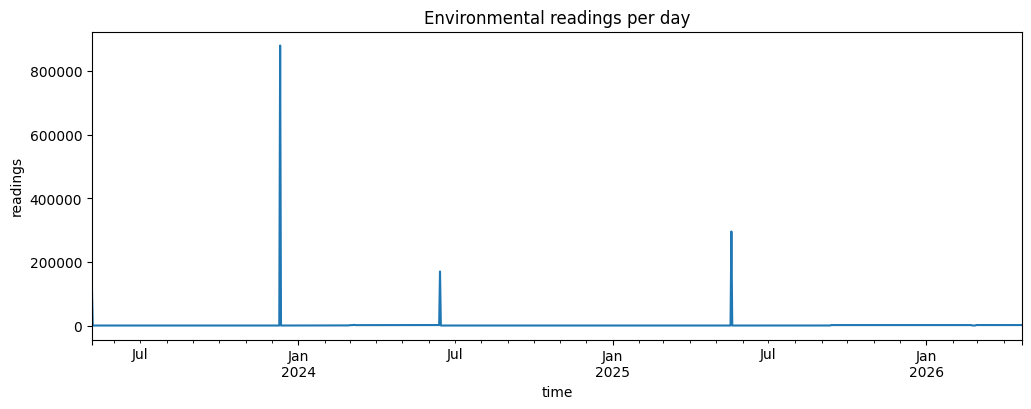

In [19]:
per_day = env.dropna(subset=["time"]).set_index("time").resample("D").size()
ax = per_day.plot(figsize=(12, 4), title="Environmental readings per day")
ax.set_ylabel("readings");

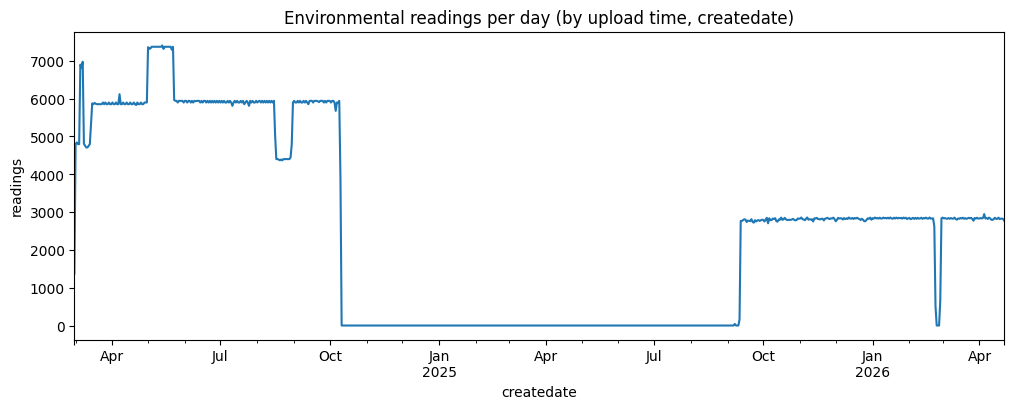

In [20]:
# Same plot as above, but grouped by createdate (when each upload reached the database)
# instead of time (the timestamp the sensor stamped on each reading).
# If some sensor clocks were frozen, this should spread the huge spikes back out over
# the days the readings actually arrived.
per_day_created = env.set_index("createdate").resample("D").size()
ax = per_day_created.plot(figsize=(12, 4), title="Environmental readings per day (by upload time, createdate)")
ax.set_ylabel("readings");

> ✍️ 
TIME:
Huge amounts of readings on 4 different days. Other days are not 0, just far fewer readings that it is barely noticeable.
Likely due to frozen, clock not actually that 4 days had immense amounts of readings
Consider usingg createdate as time variable rather than time. 

CREATEDATE:
Much more plausible readings counts. Although there is a large gap from Oct 2024 - Oct 2025, the  readings appear to follow a mostly steady average outside of this time frame.
Must consider however, that createdate is when the data arrived, not when it was measured. Measurements could potentially be hours or even days out. Must consider in limitations and analysis.

### B5. Sensors

In [21]:
print("Distinct environmental sensors:", env["sensorid"].nunique())
env.groupby("sensorid")["record_id"].nunique().describe()   # uploads per sensor

Distinct environmental sensors: 5


count        5.000000
mean     35889.400000
std      22004.698982
min      10926.000000
25%      21363.000000
50%      29341.000000
75%      58908.000000
max      58909.000000
Name: record_id, dtype: float64

In [22]:
# How often does a sensor report? Time between consecutive uploads for each sensor (minutes).
uploads = env.drop_duplicates("record_id").dropna(subset=["time"]).sort_values(["sensorid", "time"])
gaps = uploads.groupby("sensorid")["time"].diff().dt.total_seconds() / 60
gaps.describe()

count    179442.000000
mean         11.990213
std        2804.734723
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      916148.550000
Name: time, dtype: float64

> ✍️ 
Again, time between sensor uploads is unlikely to actually be the values in this.
A standard deviation of 2804 minutes for a mean of 11.9 minutes is extremely large and likely physically unplausible.
Further reinforcement that createdate is a better time variable/ measurement than time.

### B5b. When does each environmental sensor transmit, and is it continuous?
Same idea as A4b for the occupancy spaces. The table compares each sensor's number of uploads with its number of *different* measurement times. The plot shows uploads per day by **measurement time** (`time`), on a log scale; breaks in a line are days with no uploads.

In [23]:
# One row per upload (a CSV record): its sensor and the measurement time stamped on it.
# (All readings in one upload share the same time, so we keep the first per record.)
env_uploads = env.dropna(subset=["time"]).drop_duplicates("record_id")[["record_id", "sensorid", "time"]]

# First and last stamped time, number of uploads, and number of DIFFERENT measurement
# times for each sensor. If 'distinct_times' is much smaller than 'uploads', many
# uploads are repeats of the same old reading.
env_span = (env_uploads.groupby("sensorid")
                   .agg(first=("time", "min"),
                        last=("time", "max"),
                        uploads=("record_id", "size"),
                        distinct_times=("time", "nunique"))
                   .sort_values("first"))
env_span

,first,last,uploads,distinct_times
sensorid,,,,
6012002000777,2023-05-06 08:42:45+10:00,2023-05-06 08:42:45+10:00,10926,1
6012002000326,2023-12-11 16:00:57+11:00,2026-04-22 23:12:41+10:00,58909,29039
6012002000227,2023-12-11 16:07:53+11:00,2023-12-11 16:07:53+11:00,21363,1
6012002000241,2023-12-11 16:52:45+11:00,2025-05-19 23:08:04+10:00,58908,2
6012002000869,2024-02-29 17:04:56+11:00,2024-06-14 03:45:44+10:00,29341,13800


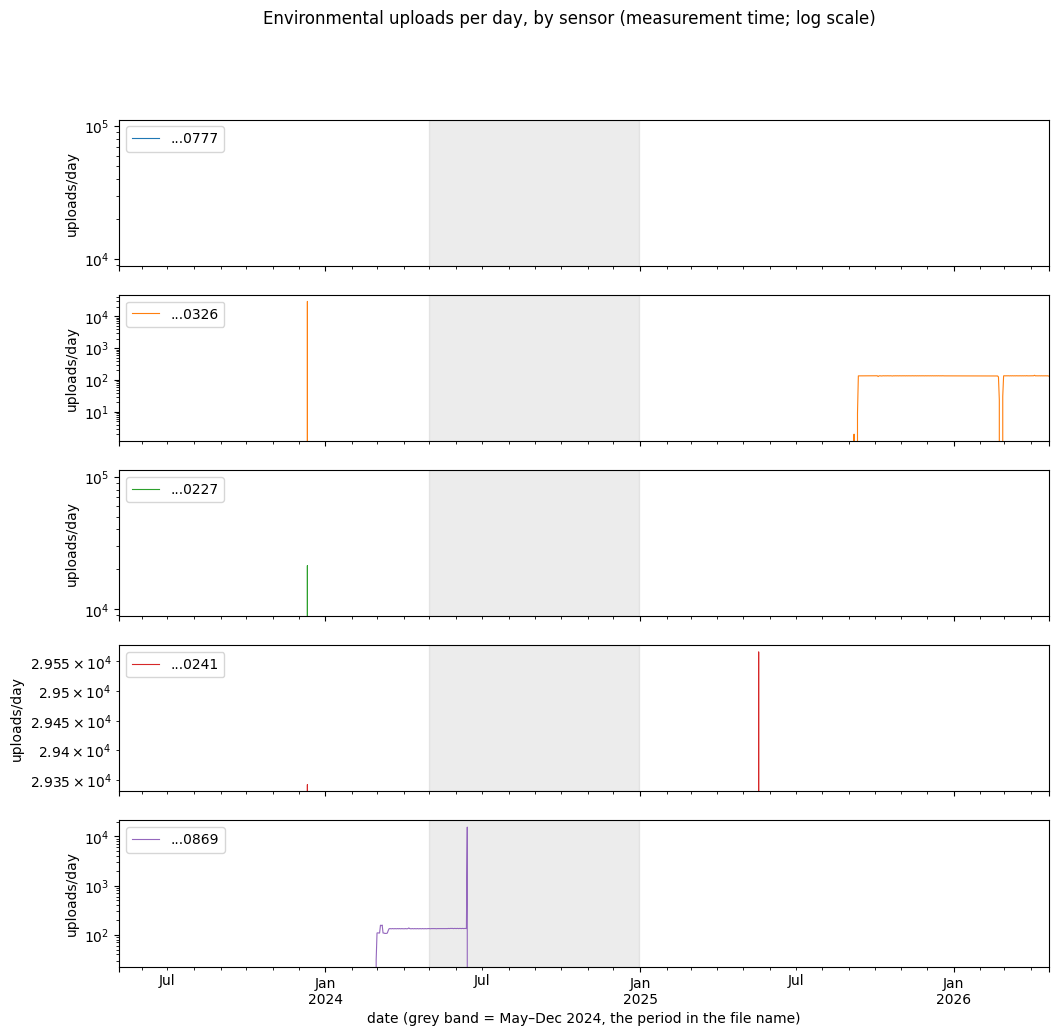

In [24]:
# Count uploads per sensor per day, using the measurement time stamped on each reading.
env_daily = (env_uploads.groupby(["sensorid", pd.Grouper(key="time", freq="D")])
                    .size()
                    .unstack(level=0)
                    .fillna(0))

# Every day in the whole period gets a row, so days with no uploads are 0, not skipped.
env_days = pd.date_range(env_daily.index.min(), env_daily.index.max(), freq="D")
env_daily = env_daily.reindex(env_days, fill_value=0)

# Order by first time (as in the table above); label each sensor by its last 4 digits.
env_daily = env_daily[env_span.index]
env_daily.columns = [f"...{str(c)[-4:]}" for c in env_daily.columns]

# Log scale on the y-axis: a few days have tens of thousands of (repeated) uploads, which
# would otherwise squash normal days (~100/day) flat. On a log axis, 0 cannot be drawn,
# so days with NO uploads show up as breaks in the line.
axes = env_daily.plot(subplots=True, sharex=True, figsize=(12, 11), linewidth=0.8, logy=True,
                      title="Environmental uploads per day, by sensor (measurement time; log scale)")
for ax in axes:
    ax.set_ylabel("uploads/day")
    ax.axvspan(pd.Timestamp("2024-05-01", tz="Australia/Melbourne"),
               pd.Timestamp("2024-12-31", tz="Australia/Melbourne"), color="grey", alpha=0.15)
    ax.legend(loc="upper left")
axes[-1].set_xlabel("date (grey band = May–Dec 2024, the period in the file name)");

In [25]:
# Summary table: the B5b table above plus the number of days each sensor has any uploads.
env_summary = env_span.copy()
env_summary.index = [f"...{str(s)[-4:]}" for s in env_summary.index]   # same labels as the plot
env_summary.index.name = "sensor"
env_summary["first"] = env_summary["first"].dt.date                    # dates only, easier to read
env_summary["last"] = env_summary["last"].dt.date
# env_daily (from the plot cell) has one column per sensor and one row per day:
# count the days where that sensor had at least one upload.
env_summary["days_with_uploads"] = (env_daily > 0).sum()
env_summary

,first,last,uploads,distinct_times,days_with_uploads
sensor,,,,,
...0777,2023-05-06,2023-05-06,10926,1,1
...0326,2023-12-11,2026-04-22,58909,29039,223
...0227,2023-12-11,2023-12-11,21363,1,1
...0241,2023-12-11,2025-05-19,58908,2,2
...0869,2024-02-29,2024-06-14,29341,13800,107


For analysis, will have to consider the span of each sensor. 
Only two sensors transmit usable, distinct values (...0326 and ...0869)
Of these two working sensors, ...0869 has a much smaller timeframe for which it is transmitting, will need to consider this timeframe in analysis

### B6. One sensor, one week
Temperature and CO₂ for the sensor with the most readings, over one week.

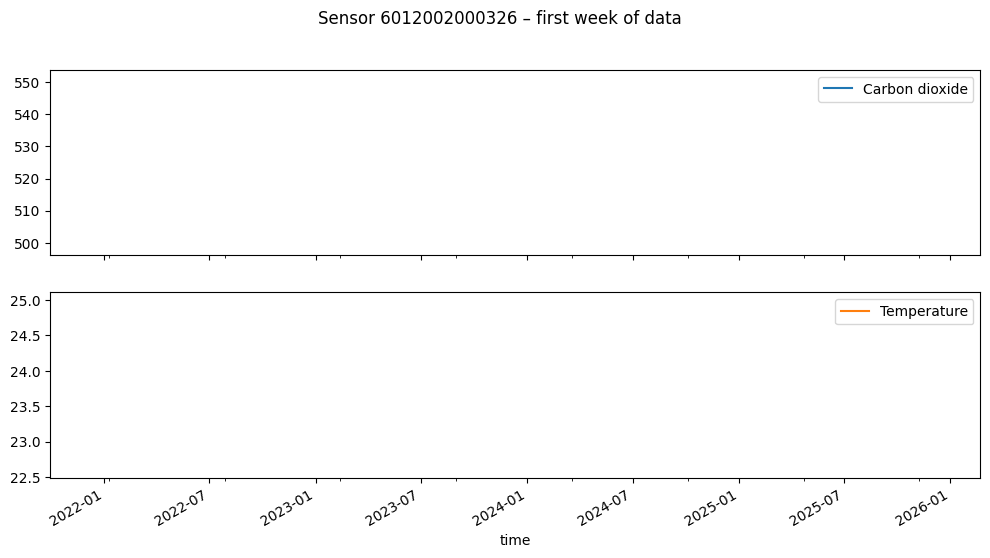

In [ ]:
top_sensor = env["sensorid"].value_counts().index[0]
s = env[(env["sensorid"] == top_sensor) & env["variable"].isin(["Temperature", "Carbon dioxide"])]

# Pivot to one column per variable so both can be plotted against time.
wide = s.pivot_table(index="time", columns="variable", values="value", observed=True)
start = wide.index.min()
week = wide[start : start + pd.Timedelta(days=7)]

week.plot(subplots=True, figsize=(12, 6), title=f"Sensor {top_sensor} – first week of data");

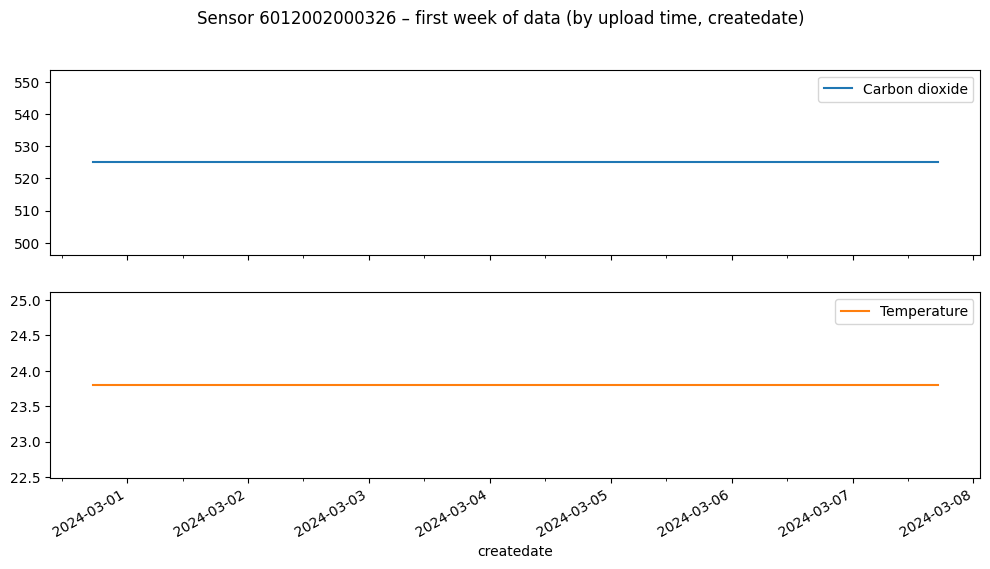

In [ ]:
# Same sensor and variables as above, but plotted against createdate (upload time).
# All readings in one upload share the same createdate, so this shows one point per upload.
wide_created = s.pivot_table(index="createdate", columns="variable", values="value", observed=True)
start_c = wide_created.index.min()
week_c = wide_created[start_c : start_c + pd.Timedelta(days=7)]

week_c.plot(subplots=True, figsize=(12, 6), title=f"Sensor {top_sensor} – first week of data (by upload time, createdate)");

> ✍️ 
No data at all when using time as time variable, again highlights the frozen clock hypothesis.
However, when compared when using createdate as the time variabble, the reading is totally constant over multiple days.
This is physically unlikely, and highlights a new issue. 
Using createdate as the time variable does'nt fix the data freezing issue, it just spreads them out over multiple days, the actual value of the reading stays frozen with the time clock.
As it turns out, 76% of the data is duplicates, and will need to be cleaned and removed for analysis. 

---
## Part C – Linking sensors to locations

The spreadsheet maps sensor IDs to buildings and rooms. For the data to be usable by location,
the IDs in the data need to match the IDs in the spreadsheet.

In [ ]:
env_loc, occ_loc = load_sensor_locations()
env_loc.head()

,Building,Floor/Room,Area,Physical Label,Sensor,ID
0,60,1-PS01,Corridor,ES1104,Env,6012003000486
1,69,1-PS02,Breakout,ES2113,Env,6012003000882
2,60,1.40,Board Room,ES1102,Env,6012003000462
3,60,1.41,Open Office,ES1110,Env,6012003000424
4,60,1.41A,Focus Room 1,ES1101,Env,6012003000448


In [ ]:
occ_loc.head()

,Building,Floor/Room,Area,ID,Note,FloorId,SpaceId
0,60,1-PS01,NaN,8034-2812-ae89,NaN,94fda9ec-e483-460e-96ce-5767c791c1c1,fe553808-899c-43a3-96f7-f444f41f3046
1,60,1-PS01,NaN,8034-2812-c28f,NaN,94fda9ec-e483-460e-96ce-5767c791c1c1,bd7e25c4-beb5-4d17-9426-859cacfd0f03
2,60,1-PS01,NaN,8034-2812-bfc5,NaN,94fda9ec-e483-460e-96ce-5767c791c1c1,67235649-ade6-43d7-a216-180d6dd8e3c1
3,60,1-PS01,NaN,8034-2812-cc64,NaN,94fda9ec-e483-460e-96ce-5767c791c1c1,7ac9618b-5096-41a1-85d9-2db3541075e6
4,60,1.38,NaN,8034-2812-ecc1,NaN,94fda9ec-e483-460e-96ce-5767c791c1c1,56d7400d-7933-4e4e-9ecc-e5da4c8f991d


In [ ]:
# What fraction of the sensor IDs in the DATA appear in the SPREADSHEET?
env_ids_data = set(env["sensorid"].unique())
env_ids_sheet = set(env_loc["ID"])
print(f"Env sensors in data: {len(env_ids_data)}, in spreadsheet: {len(env_ids_sheet)}, "
      f"matching: {len(env_ids_data & env_ids_sheet)}")

space_ids_data = set(occ["floorspaceid"].unique())
print(f"Floor spaces in data: {len(space_ids_data)}, "
      f"matching SpaceId: {len(space_ids_data & set(occ_loc['SpaceId']))}, "
      f"matching FloorId: {len(space_ids_data & set(occ_loc['FloorId']))}")

Env sensors in data: 5, in spreadsheet: 77, matching: 1
Floor spaces in data: 5, matching SpaceId: 2, matching FloorId: 0


In [ ]:
# Compare a few IDs side by side to see how they differ.
print("Data env IDs:       ", sorted(env_ids_data)[:5])
print("Spreadsheet env IDs:", sorted(env_ids_sheet)[:5])

Data env IDs:        [np.int64(6012002000227), np.int64(6012002000241), np.int64(6012002000326), np.int64(6012002000777), np.int64(6012002000869)]
Spreadsheet env IDs: [6012002000555, 6012002000692, 6012002000715, 6012002000722, 6012002000739]


> ✍️ Overall analysis: there is very little matchup between known locations and usable data.
For env: There is only one out of the five env sensors for which there is a known match in spreadsheet and with genuine data entries (sensor ...0869)
For occ: Only two of the five floor spaces have matches in the spreadsheet and therefore a known location.

---
## Summary – what did the audit find?

After auditing, unfortunately much of the data is unusable. Many of the sensors for both occupancy and env don't have matches within the lookup spreadsheet and therefore have no known location. The amount of unknowns increase when considering the fact that all of the floorspace ID's listed for the occupancy data have been labelled as wrong, leading for it to be impossible to compare two different rooms or spaces across the same timeframe. 

For the env sensors approximately 76% of the env data is repeated measurements from what is hypothesised to be a frozen sensor. Furthermore, out of the 5 env sensors only two appear to transmit genuine data, with one of them transmitting over a much shorter timeframe than the other (shortest timeframe spanning 29/02/2024 - 14/06/2024). 

As for occupancy sensors, while there is much more available genuine data, the sensors also suffer from the same transmitting timeframee issue. Although the dataset starts and ends from Nov 2023 - Apr 2026. However, not all the sensors transmit across the same timeframe, and the only overlap that exists for comparison is May 2024 - Dec 2024. 

